<a href="https://colab.research.google.com/github/deburg0/udlbook/blob/main/Balduzzi.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [28]:
import torch
import torch.nn as nn

class BalduzziModel(nn.Module):
    def __init__(self, num_hidden_layers, num_neurons_per_layer):
        super(BalduzziModel, self).__init__()
        self.num_hidden_layers = num_hidden_layers
        self.num_neurons_per_layer = num_neurons_per_layer

        layers = []

        # Input layer
        layers.append(nn.Linear(1, num_neurons_per_layer))
        layers.append(nn.ReLU()) # Rectifier neuron

        # Hidden layers
        for _ in range(num_hidden_layers - 1): # -1 because the first hidden layer is combined with input
            layers.append(nn.Linear(num_neurons_per_layer, num_neurons_per_layer))
            layers.append(nn.ReLU()) # Rectifier neuron

        # Output layer
        layers.append(nn.Linear(num_neurons_per_layer, 1))

        self.model = nn.Sequential(*layers)

    def forward(self, x):
        return self.model(x)

# Example usage:
# D = number of hidden layers, N = number of neurons per layer
D = 24 # For example, 24 hidden layers
N = 200 # 200 rectifier neurons per hidden layer

model = BalduzziModel(num_hidden_layers=D, num_neurons_per_layer=N)

#print(f"Model with {D} hidden layers and {N} neurons per layer:")
##print(model)

# Test with some dummy input
#dummy_input = torch.randn(10, 1) # Batch size of 10, 1 input feature
#output = model(dummy_input)
#print("\nOutput shape:", output.shape)


In [2]:
import numpy as np
import matplotlib.pyplot as plt

In [9]:
X = np.linspace(-2,2, 256)
Xin = X.reshape(-1,1)


In [29]:
y = model(torch.tensor(Xin).float())

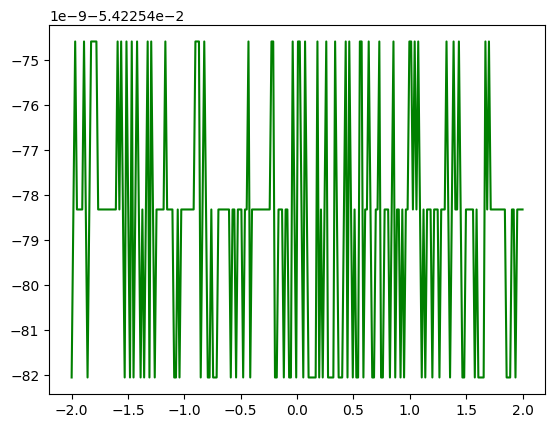

In [30]:
plt.plot(X, y.detach().numpy(),'g')
plt.show()

In [25]:
import torch

# Create a sample input tensor and set requires_grad=True
# This tells PyTorch to store gradients for this tensor during computation
input_tensor = torch.tensor([-0.5], dtype=torch.float32, requires_grad=True)

# Perform a forward pass through the model
output_tensor = model(input_tensor.unsqueeze(0)) # Unsqueeze to add a batch dimension

# Calculate gradients. If the output is a scalar, we can call .backward() directly.
# If it's not a scalar, you usually need to pass a 'gradient' argument, e.g., torch.ones_like(output_tensor).
# For a single output neuron, it's effectively a scalar.
output_tensor.backward()

# The gradients of the output with respect to the input are now in input_tensor.grad
print(f"Input tensor: {input_tensor}")
print(f"Output tensor: {output_tensor}")
print(f"Gradient of output with respect to input: {input_tensor.grad}")


Input tensor: tensor([-0.5000], requires_grad=True)
Output tensor: tensor([[0.0399]], grad_fn=<AddmmBackward0>)
Gradient of output with respect to input: tensor([-1.1163e-07])


In [31]:
# 1. Convert Xin to a PyTorch tensor with requires_grad=True
input_vector_tensor = torch.tensor(Xin, dtype=torch.float32, requires_grad=True)

# 2. Perform a forward pass through the model
output_vector_tensor = model(input_vector_tensor)

# 3. To get gradients for each input, we typically calculate the gradient
#    of a scalar loss (e.g., the sum of outputs) with respect to the inputs.
#    This will give a gradient tensor of the same shape as the input, where
#    each element represents d(sum_of_outputs) / d(input_element).
output_sum = output_vector_tensor.sum()
output_sum.backward()

# The gradients are now stored in input_vector_tensor.grad
gradients = input_vector_tensor.grad

print(f"Input vector shape: {input_vector_tensor.shape}")
print(f"Output vector shape: {output_vector_tensor.shape}")
print(f"Gradients shape: {gradients.shape}")
print(f"First 5 input values:\n{input_vector_tensor[:5].detach().numpy()}")
print(f"First 5 output values:\n{output_vector_tensor[:5].detach().numpy()}")
print(f"First 5 gradient values:\n{gradients[:5].numpy()}")

# For plotting the output of the model (as in cell n-ivBWbsl41_), we can use:
y_values_for_plot = output_vector_tensor.detach().numpy()
# Note: This is similar to what J7ddVU25odMz does, but now using the requires_grad=True tensor


Input vector shape: torch.Size([256, 1])
Output vector shape: torch.Size([256, 1])
Gradients shape: torch.Size([256, 1])
First 5 input values:
[[-2.       ]
 [-1.9843137]
 [-1.9686275]
 [-1.9529412]
 [-1.9372549]]
First 5 output values:
[[-0.05422548]
 [-0.05422548]
 [-0.05422547]
 [-0.05422548]
 [-0.05422548]]
First 5 gradient values:
[[1.5883350e-10]
 [1.5883350e-10]
 [1.4621859e-10]
 [1.4621859e-10]
 [1.4621859e-10]]


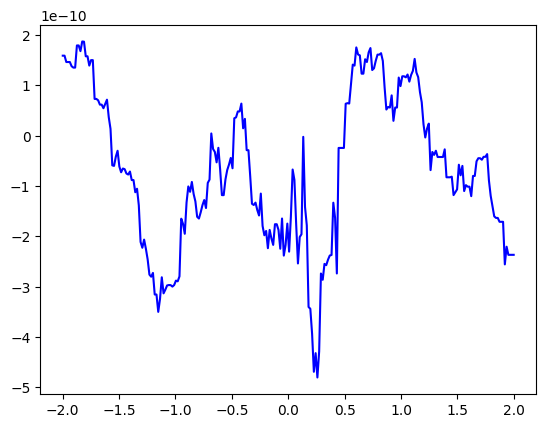

In [32]:
plt.plot(X,gradients.detach().numpy(),'b')
plt.show()